DADOS: estado do Rio de Janeiro; 12 censos (1872–2010); P0=1.057.696 fixado.
MÉTODO: mínimos quadrados não lineares; Newton amortecido com Hessiana exata,
        validado por scipy.optimize.least_squares; unidades escaladas.
Newton: 6 passos; r=0.023560352/ano; K=40,286,048 habitantes.
SciPy:  r=0.023560352/ano; K=40,286,049 habitantes.
Logístico: RMSE=658,224; MAE=520,453; R²=0.983884.
Maior erro absoluto=1,191,334 habitantes.
Condicionamento da Jacobiana escalada (sem 1872): 422.557.
Exponencial: k=0.020382467/ano; RMSE=894,180; R²=0.970259.
Validação: ajuste até 2000 -> 2010 previsto=17,726,529; observado=15,989,929; erro=1,736,600 habitantes (10.86%).
ATENÇÃO: K é parâmetro do modelo e os censos históricos têm limitações de comparabilidade.
RMSE e R² no ajuste completo são descritivos; não representam desempenho futuro.

Tabela completa:
  ano  populacao_ibge  populacao_ajustada  residuo_ajustado_menos_observado  erro_relativo_percentual
1872         1057696       1,057,696.000   

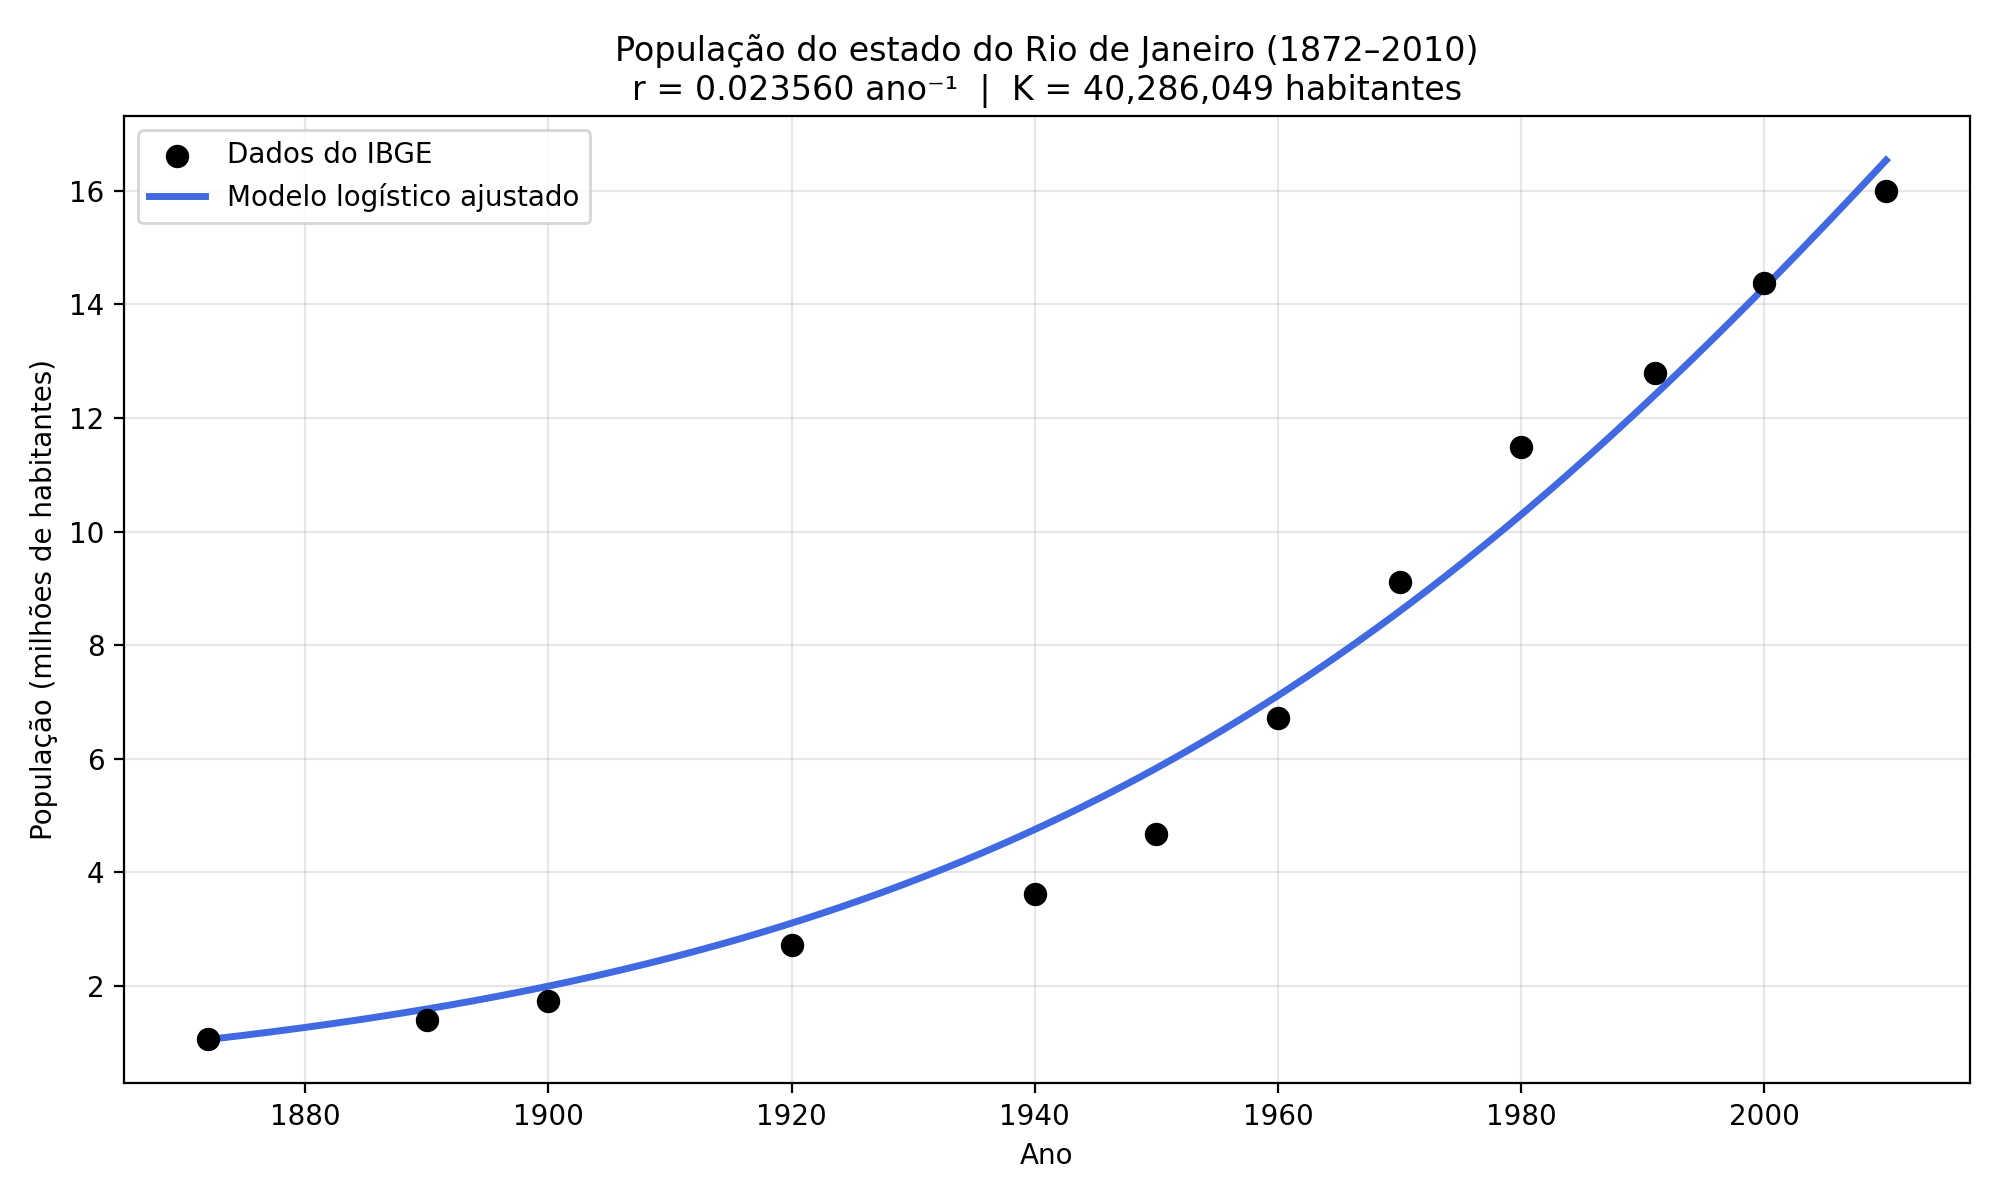

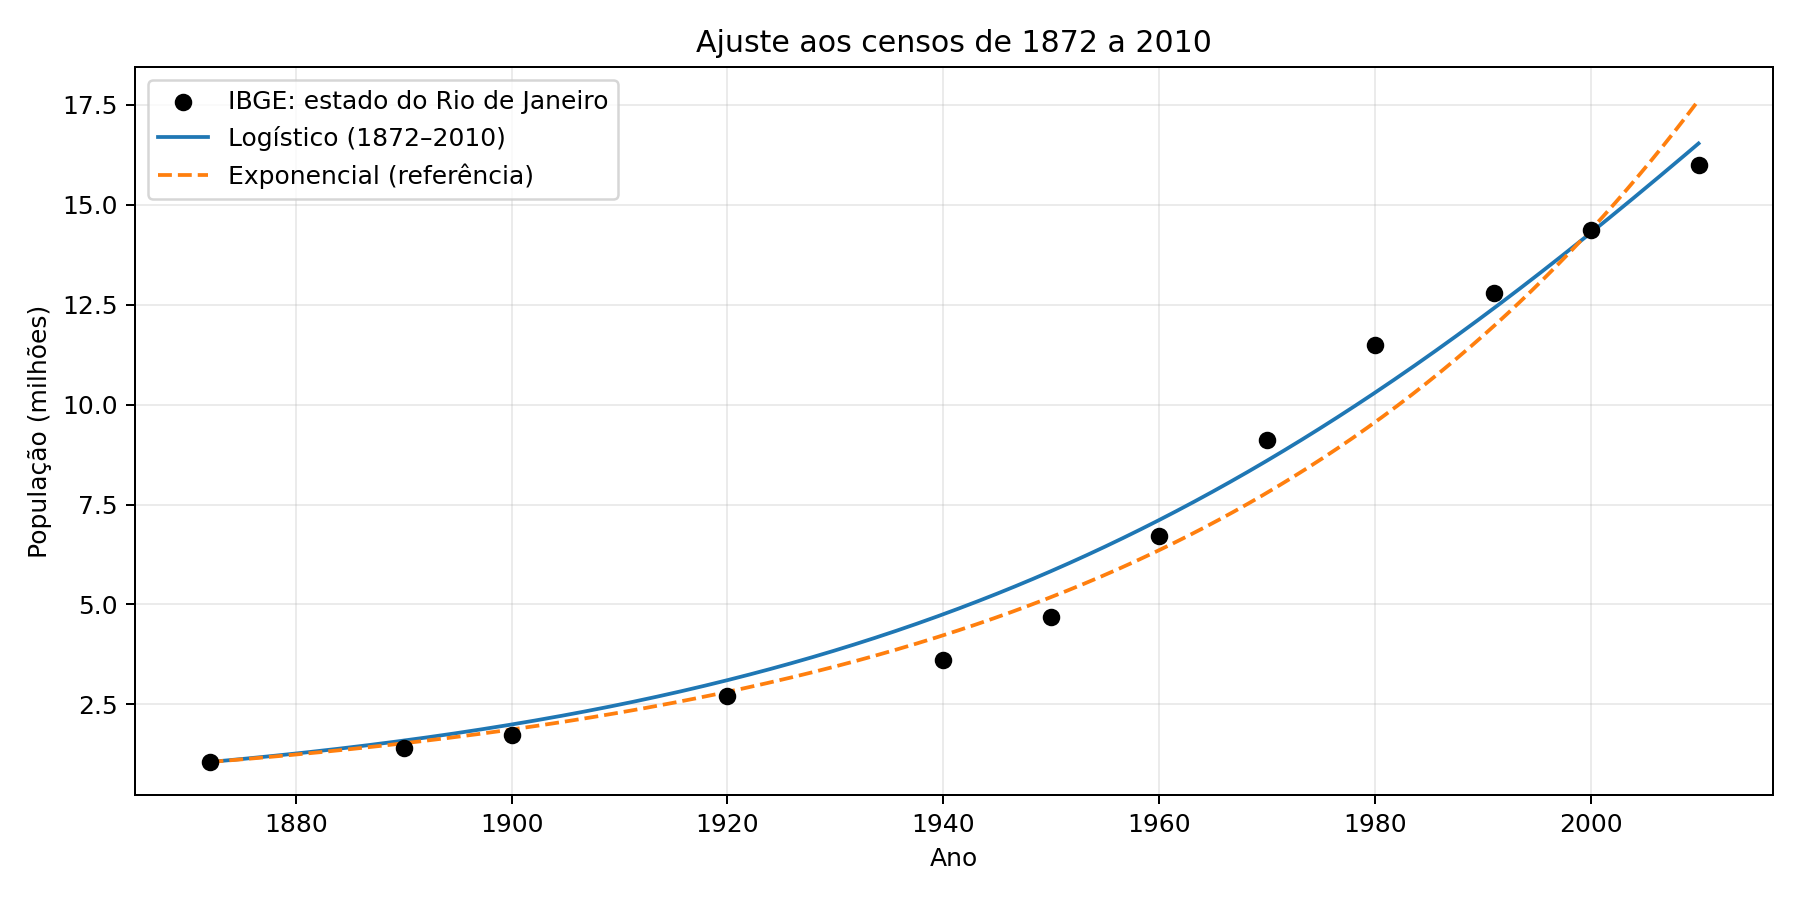

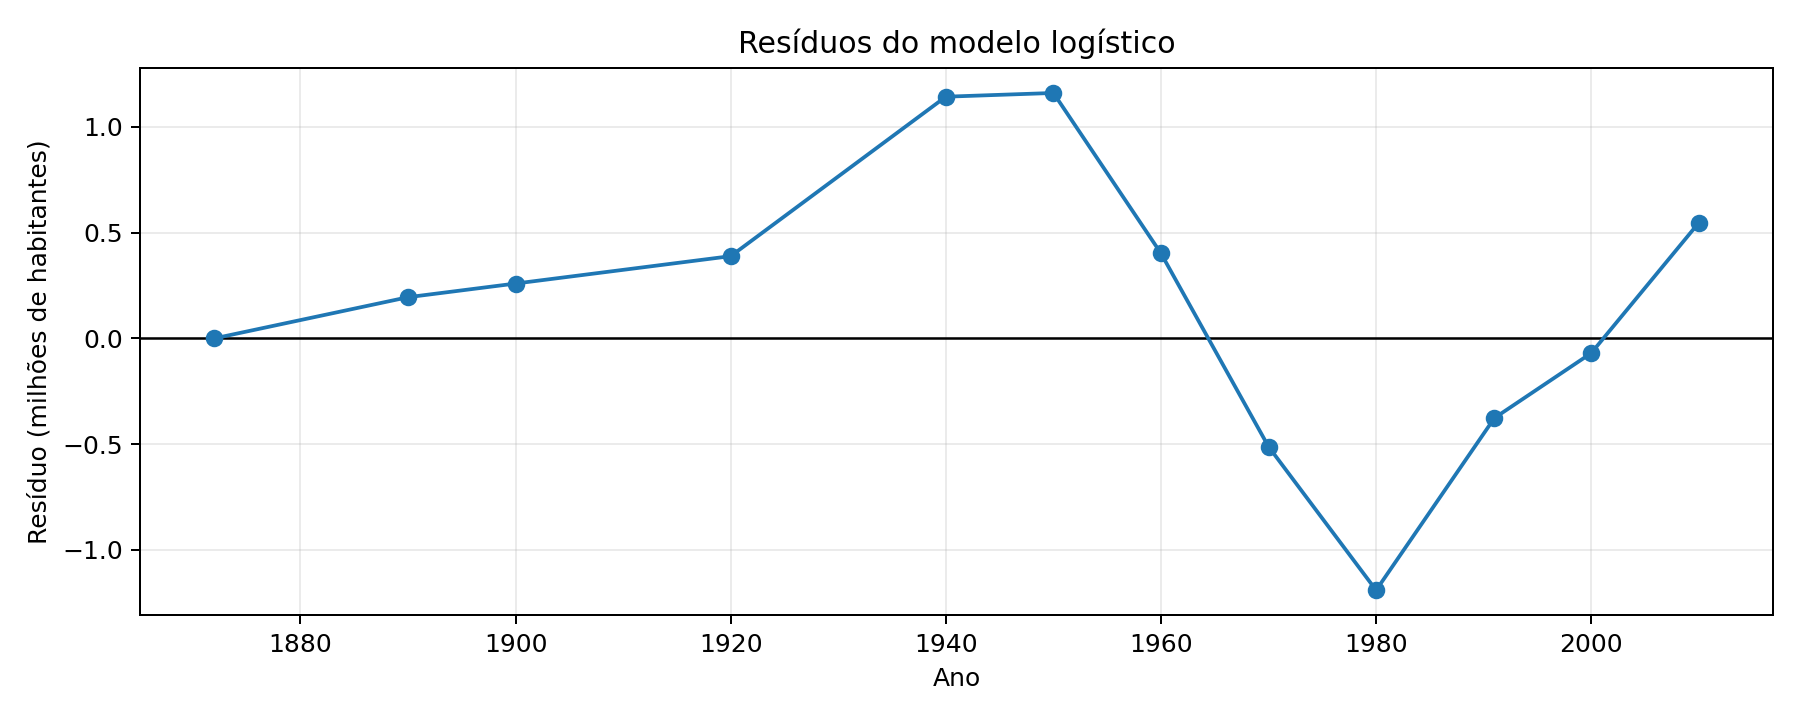

In [ ]:
"""Ajusta Verhulst à série censitária do ESTADO do Rio de Janeiro (1872–2010).

Uso:
    python regressao_logistica_rio.py --csv upload/20260921091819.csv

Dependências: numpy, scipy, pandas, matplotlib, scikit-learn.
As iterações de Newton são implementadas abaixo; SciPy faz a checagem
independente por mínimos quadrados não lineares com restrições.
"""

from __future__ import annotations

import argparse
import csv
from pathlib import Path

import matplotlib

from IPython.display import display, Image

#matplotlib.use("Agg")  # permite salvar figuras sem interface gráfica
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import least_squares
from sklearn.metrics import mean_absolute_error, r2_score


MILHAO = 1_000_000.0
SECULO = 100.0


def carregar_serie(arquivo: Path) -> tuple[np.ndarray, np.ndarray]:
    """Lê o CSV peculiar do IBGE: cabeçalho ano#ano, separador ';'."""
    with arquivo.open("r", encoding="utf-8-sig", newline="") as f:
        linhas = list(csv.reader(f, delimiter=";"))
    cabecalho = next(
        (linha for linha in linhas if len(linha) > 2 and linha[1].strip().startswith("1872")),
        None,
    )
    registro = next(
        (linha for linha in linhas if linha and linha[0].strip() == "Rio de Janeiro"),
        None,
    )
    if cabecalho is None or registro is None:
        raise ValueError("Não foi possível identificar o cabeçalho e a linha 'Rio de Janeiro'.")
    anos = np.array([int(c.split("#", 1)[0]) for c in cabecalho[1:]], dtype=int)
    populacao = np.array([int(c) for c in registro[1:1 + len(anos)]], dtype=float)
    if len(anos) != len(populacao) or len(anos) < 4 or not np.all(np.diff(anos) > 0):
        raise ValueError("Série incompleta ou anos fora de ordem.")
    if anos[0] != 1872 or anos[-1] != 2010 or np.any(populacao <= 0):
        raise ValueError("Esperava-se a série positiva de 1872 a 2010.")
    return anos, populacao


def modelo(q: np.ndarray, t: np.ndarray, p0: float) -> np.ndarray:
    """q=(r por século, K em milhões), t em séculos, p0 em milhões."""
    taxa, k = q
    a = k / p0 - 1.0
    e = np.exp(-taxa * t)
    return k / (1.0 + a * e)


def derivadas_modelo(
    q: np.ndarray, t: np.ndarray, p0: float
) -> tuple[np.ndarray, np.ndarray]:
    """Jacobiana n x 2 e derivadas segundas n x 2 x 2 do modelo."""
    taxa, k = q
    a = k / p0 - 1.0
    e = np.exp(-taxa * t)
    d = 1.0 + a * e
    j = np.column_stack((k * t * a * e / d**2, (1.0 - e) / d**2))
    h = np.zeros((len(t), 2, 2))
    h[:, 0, 0] = k * t**2 * a * e * (a * e - 1.0) / d**3
    h[:, 0, 1] = t * e * (d + 2.0 * a * (1.0 - e)) / d**3
    h[:, 1, 0] = h[:, 0, 1]
    h[:, 1, 1] = -2.0 * e * (1.0 - e) / (p0 * d**3)
    return j, h


def objetivo_gradiente_hessiana(
    q: np.ndarray, t: np.ndarray, y: np.ndarray, p0: float
) -> tuple[float, np.ndarray, np.ndarray]:
    e = modelo(q, t, p0) - y
    j, h_modelo = derivadas_modelo(q, t, p0)
    s = 0.5 * float(e @ e)
    gradiente = j.T @ e
    hessiana = j.T @ j + np.einsum("i,ijk->jk", e, h_modelo)
    return s, gradiente, hessiana


def newton_amortecido(
    q0: np.ndarray, t: np.ndarray, y: np.ndarray, p0: float,
    max_iter: int = 120,
) -> tuple[np.ndarray, list[tuple[int, float, float, float, float]]]:
    """Newton exato em grad S=0 com busca linear e restrições de domínio."""
    q = np.asarray(q0, dtype=float).copy()
    k_min = float(np.max(y)) + 1e-10
    historico = []
    for it in range(max_iter):
        s, grad, hess = objetivo_gradiente_hessiana(q, t, y, p0)
        historico.append((it, float(q[0]), float(q[1]), s, float(np.linalg.norm(grad))))
        if np.linalg.norm(grad, ord=np.inf) < 1e-9:
            if np.linalg.eigvalsh(hess).min() <= 0:
                raise RuntimeError("Ponto estacionário sem hessiana positiva.")
            return q, historico
        try:
            direcao = np.linalg.solve(hess, -grad)
        except np.linalg.LinAlgError as exc:
            raise RuntimeError("Hessiana singular na iteração de Newton.") from exc
        if grad @ direcao >= 0:
            raise RuntimeError("Passo de Newton não é uma direção de descida.")
        passo = 1.0
        while passo > 2.0**-45:
            candidato = q + passo * direcao
            if candidato[0] > 0 and candidato[1] > k_min:
                novo_s = objetivo_gradiente_hessiana(candidato, t, y, p0)[0]
                if novo_s <= s + 1e-4 * passo * (grad @ direcao):
                    q = candidato
                    break
            passo *= 0.5
        else:
            raise RuntimeError("Busca linear sem passo aceitável; teste outro início.")
    raise RuntimeError("Newton não convergiu dentro do limite de iterações.")


def metricas(y: np.ndarray, estimado: np.ndarray) -> dict[str, float]:
    residuo = estimado - y
    return {
        "rmse_milhoes": float(np.sqrt(np.mean(residuo**2))),
        "mae_milhoes": float(mean_absolute_error(y, estimado)),
        "r2": float(r2_score(y, estimado)),
        "maior_erro_milhoes": float(np.max(np.abs(residuo))),
    }


def main() -> None:
    parser = argparse.ArgumentParser(description=__doc__)

    # Caminho completo do CSV no seu computador
    parser.add_argument(
        "--csv",
        type=Path,
        default=Path(
            r"/content/20260921091819.csv.csv"
        ),
        help="CSV baixado do IBGE com a linha Rio de Janeiro (estado)",
    )

    # Pasta onde serão salvos os resultados
    parser.add_argument(
        "--saida",
        type=Path,
        default=Path.cwd() / "resultados_rio",
    )

    # Evita interpretar os argumentos internos do Jupyter
    args = parser.parse_args([])

    if not args.csv.is_file():
        raise FileNotFoundError(
            f"Arquivo CSV não encontrado: {args.csv}\n"
            "Confira o nome do arquivo e o caminho informado em --csv."
        )

    args.saida.mkdir(parents=True, exist_ok=True)

    anos, populacao = carregar_serie(args.csv)
    y = populacao / MILHAO
    t = (anos - anos[0]) / SECULO
    p0 = y[0]  # população inicial fixada no primeiro censo

    # Comparação com SciPy: mínimos quadrados não lineares, com limites explícitos.
    minimo_k = float(np.max(y)) + 1e-8
    inicio = np.array([2.3, 40.0])
    ajuste = least_squares(
        lambda q: modelo(q, t, p0) - y,
        x0=inicio,
        jac=lambda q: derivadas_modelo(q, t, p0)[0],
        bounds=([1e-8, minimo_k], [20.0, 1e6]),
        method="trf", ftol=1e-13, xtol=1e-13, gtol=1e-13, max_nfev=10000,
    )
    if not ajuste.success:
        raise RuntimeError(f"Falha no ajuste SciPy: {ajuste.message}")

    # O Newton generalizado é aplicado a grad S(r,K)=0, usando a Hessiana exata.
    q_newton, historico = newton_amortecido(inicio, t, y, p0)
    q = ajuste.x

    ####

    ##

    if not np.allclose(q, q_newton, rtol=1e-5, atol=1e-6):
        raise RuntimeError("Newton e SciPy não chegaram aos mesmos parâmetros.")

    # Comparação visual: dados observados e curva logística ajustada
    anos_curva = np.linspace(anos.min(), anos.max(), 500)
    tempos_curva = (anos_curva - anos[0]) / SECULO
    populacao_curva = modelo(q, tempos_curva, p0)  # em milhões

    r_estimado = q[0] / SECULO        # por ano
    K_estimado = q[1] * MILHAO        # habitantes

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.scatter(
    anos,
    populacao / MILHAO,
    color="black",
    s=55,
    zorder=3,
    label="Dados do IBGE",
    )

    ax.plot(
    anos_curva,
    populacao_curva,
    color="royalblue",
    linewidth=2.5,
    label="Modelo logístico ajustado",
    )

    ax.set_title(
        "População do estado do Rio de Janeiro (1872–2010)\n"
        f"r = {r_estimado:.6f} ano⁻¹  |  K = {K_estimado:,.0f} habitantes"
    )
    ax.set_xlabel("Ano")
    ax.set_ylabel("População (milhões de habitantes)")
    ax.grid(alpha=0.3)
    ax.legend()

    fig.tight_layout()
    fig.savefig(args.saida / "comparacao_logistica_ibge.png", dpi=200)
    plt.show()

    previsto = modelo(q, t, p0)
    resumo_ajuste = metricas(y, previsto)
    residuos = previsto - y
    jac, _ = derivadas_modelo(q, t, p0)
    cond_jac = float(np.linalg.cond(jac[1:]))  # primeira linha é zero: P0 fixado
    tabela = pd.DataFrame({
        "ano": anos,
        "populacao_ibge": populacao.astype(int),
        "populacao_ajustada": previsto * MILHAO,
        "residuo_ajustado_menos_observado": residuos * MILHAO,
        "erro_relativo_percentual": 100 * residuos / y,
    })
    tabela.to_csv(args.saida / "ajuste_censos.csv", index=False, float_format="%.6f")
    pd.DataFrame(
        historico, columns=["iteracao", "r_por_seculo", "K_milhoes", "S_milhoes_ao_quadrado", "norma_gradiente"]
    ).to_csv(args.saida / "iteracoes_newton.csv", index=False)

    # Validação genuinamente temporal: 2010 fica fora do ajuste até 2000.
    treino = anos <= 2000
    parcial = least_squares(
        lambda v: modelo(v, t[treino], p0) - y[treino],
        x0=inicio,
        jac=lambda v: derivadas_modelo(v, t[treino], p0)[0],
        bounds=([1e-8, float(np.max(y[treino])) + 1e-8], [20, 1e6]),
        method="trf", ftol=1e-13, xtol=1e-13, gtol=1e-13,
    )
    previsto_2010 = float(modelo(parcial.x, t[-1:], p0)[0])

    # Referência: modelo exponencial P=P0 exp(k t), também com P0 fixado.
    exponencial = least_squares(
        lambda v: p0 * np.exp(v[0] * t) - y,
        x0=np.array([2.0]), bounds=([0.0], [5.0]),
    )
    pred_exp = p0 * np.exp(exponencial.x[0] * t)
    resumo_exp = metricas(y, pred_exp)

    fig, ax = plt.subplots(figsize=(10, 5))
    grade_anos = np.linspace(anos[0], anos[-1], 500)
    grade_t = (grade_anos - anos[0]) / SECULO
    ax.scatter(anos, y, color="black", zorder=3, label="IBGE: estado do Rio de Janeiro")
    ax.plot(grade_anos, modelo(q, grade_t, p0), label="Logístico (1872–2010)")
    ax.plot(grade_anos, p0 * np.exp(exponencial.x[0] * grade_t), "--", label="Exponencial (referência)")
    ax.set(xlabel="Ano", ylabel="População (milhões)", title="Ajuste aos censos de 1872 a 2010")
    ax.legend()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(args.saida / "ajuste_populacional.png", dpi=180)
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.axhline(0.0, color="black", lw=1)
    ax.plot(anos, residuos, "o-", label="Ajustado menos observado")
    ax.set(xlabel="Ano", ylabel="Resíduo (milhões de habitantes)", title="Resíduos do modelo logístico")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(args.saida / "residuos_logisticos.png", dpi=180)
    plt.close(fig)

    linhas = [
        "DADOS: estado do Rio de Janeiro; 12 censos (1872–2010); P0=1.057.696 fixado.",
        "MÉTODO: mínimos quadrados não lineares; Newton amortecido com Hessiana exata,",
        "        validado por scipy.optimize.least_squares; unidades escaladas.",
        f"Newton: {len(historico)-1} passos; r={q_newton[0]/SECULO:.9f}/ano; K={q_newton[1]*MILHAO:,.0f} habitantes.",
        f"SciPy:  r={q[0]/SECULO:.9f}/ano; K={q[1]*MILHAO:,.0f} habitantes.",
        f"Logístico: RMSE={resumo_ajuste['rmse_milhoes']*MILHAO:,.0f}; MAE={resumo_ajuste['mae_milhoes']*MILHAO:,.0f}; R²={resumo_ajuste['r2']:.6f}.",
        f"Maior erro absoluto={resumo_ajuste['maior_erro_milhoes']*MILHAO:,.0f} habitantes.",
        f"Condicionamento da Jacobiana escalada (sem 1872): {cond_jac:.3f}.",
        f"Exponencial: k={exponencial.x[0]/SECULO:.9f}/ano; RMSE={resumo_exp['rmse_milhoes']*MILHAO:,.0f}; R²={resumo_exp['r2']:.6f}.",
        f"Validação: ajuste até 2000 -> 2010 previsto={previsto_2010*MILHAO:,.0f}; observado={populacao[-1]:,.0f}; erro={(previsto_2010-y[-1])*MILHAO:,.0f} habitantes ({100*(previsto_2010/y[-1]-1):.2f}%).",
        "ATENÇÃO: K é parâmetro do modelo e os censos históricos têm limitações de comparabilidade.",
        "RMSE e R² no ajuste completo são descritivos; não representam desempenho futuro.",
    ]
    saida_texto = "\n".join(linhas)
    (args.saida / "resumo_resultados.txt").write_text(saida_texto + "\n", encoding="utf-8")
    print(saida_texto)
    print("\nTabela completa:\n", tabela.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))
    print(f"\nArquivos gravados em {args.saida.resolve()}")


if __name__ == "__main__":
  main( )

display(Image(filename="resultados_rio/comparacao_logistica_ibge.png"))
display(Image(filename="resultados_rio/ajuste_populacional.png"))
display(Image(filename="resultados_rio/residuos_logisticos.png"))

